In [1]:
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dtreeviz

from sklearn import tree
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.tree import DecisionTreeRegressor

## Data and model:

In [2]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

clf = tree.DecisionTreeClassifier(random_state=42)
clf.fit(X_iris, y_iris)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## 1. Classification:

First, scikit-learn's built-in plot of the fitted tree, for comparison:

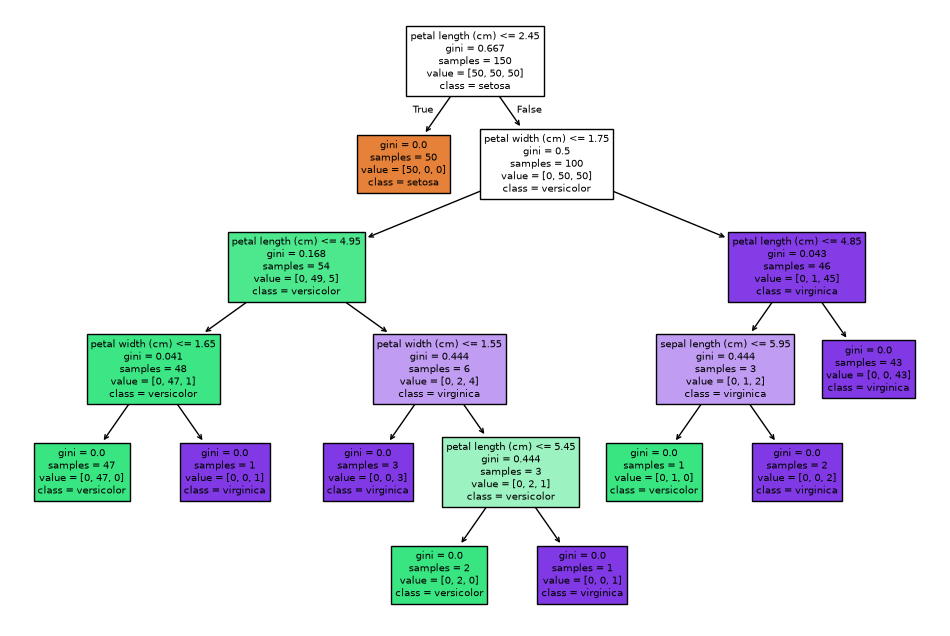

In [3]:
plt.figure(figsize=(12, 8))
tree.plot_tree(
    clf,
    filled=True,
    feature_names=iris.feature_names,
    class_names=list(iris.target_names)
)
plt.show()

The same tree with `dtreeviz`, which adds the feature distributions at each split:

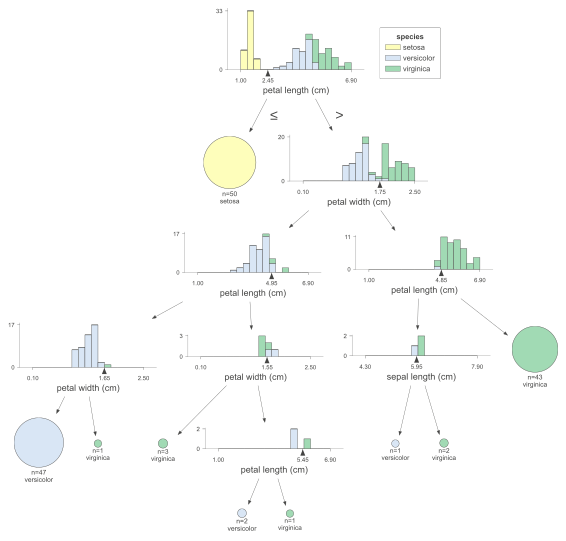

In [4]:
viz = dtreeviz.model(
    clf,
    X_train=X_iris,
    y_train=y_iris,
    feature_names=iris.feature_names,
    target_name="species",
    class_names=list(iris.target_names)
)

viz.view()

## 2. Regression:

In [5]:
housing = fetch_california_housing(as_frame=True)
X_house = housing.data.to_numpy()
y_house = housing.target.to_numpy()

regr = DecisionTreeRegressor(max_depth=1, random_state=42)
regr.fit(X_house, y_house)

viz_regr = dtreeviz.model(
    regr,
    X_train=X_house,
    y_train=y_house,
    feature_names=list(housing.feature_names),
    target_name="price"
)

viz_regr.view(scale=2)

## 3. Horizontal decision tree:

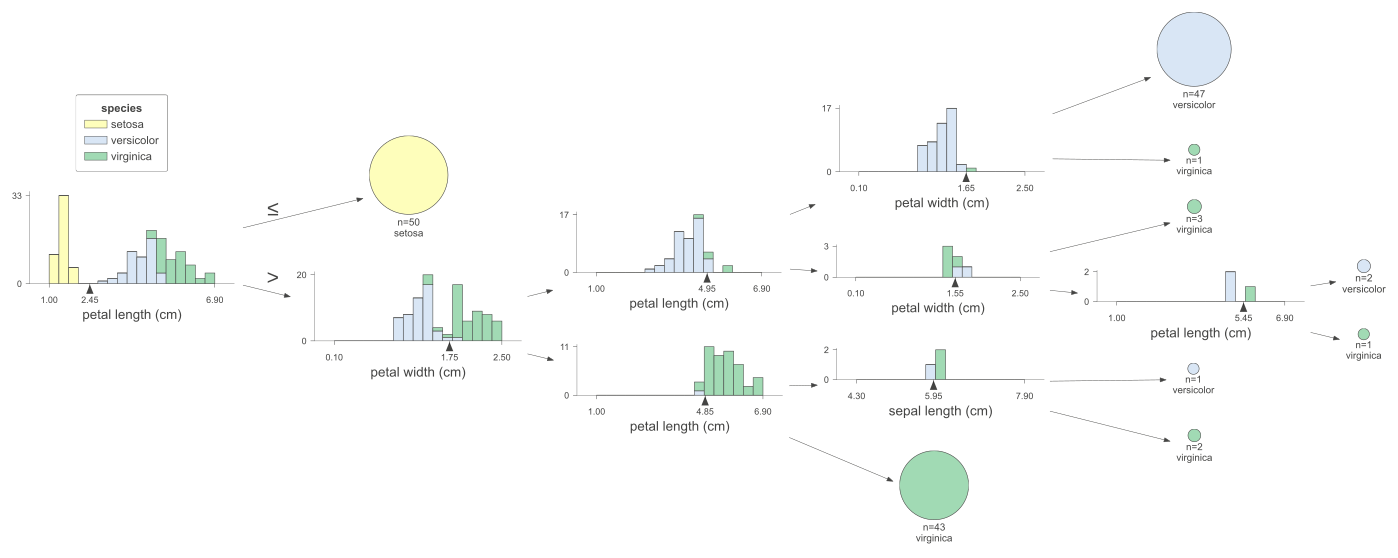

In [6]:
viz.view(scale=1.5, orientation="LR")

## 4. Show prediction path:

Sample: {'sepal length (cm)': 6.3, 'sepal width (cm)': 3.3, 'petal length (cm)': 6.0, 'petal width (cm)': 2.5}
True class: virginica


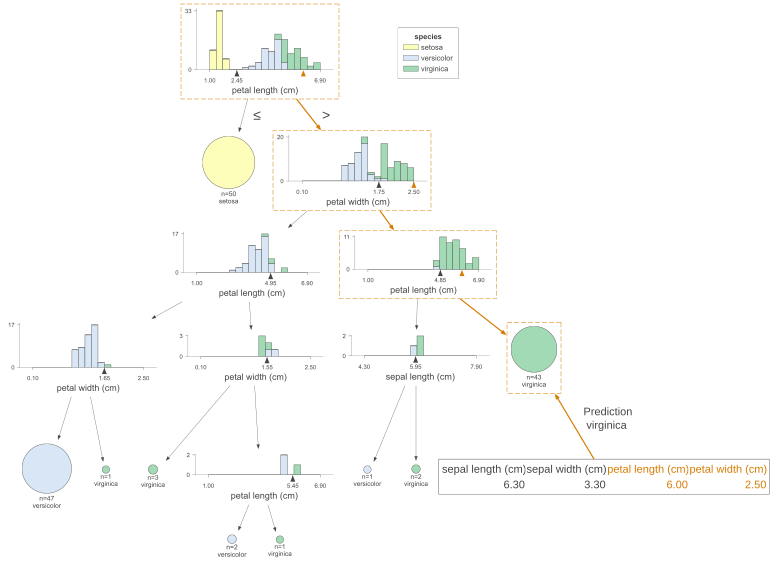

In [7]:
sample_idx = 100
x_sample = X_iris[sample_idx]

print("Sample:", dict(zip(iris.feature_names, x_sample.tolist())))
print("True class:", iris.target_names[y_iris[sample_idx]])

viz.view(x=x_sample)

## 5. Show node numbers:

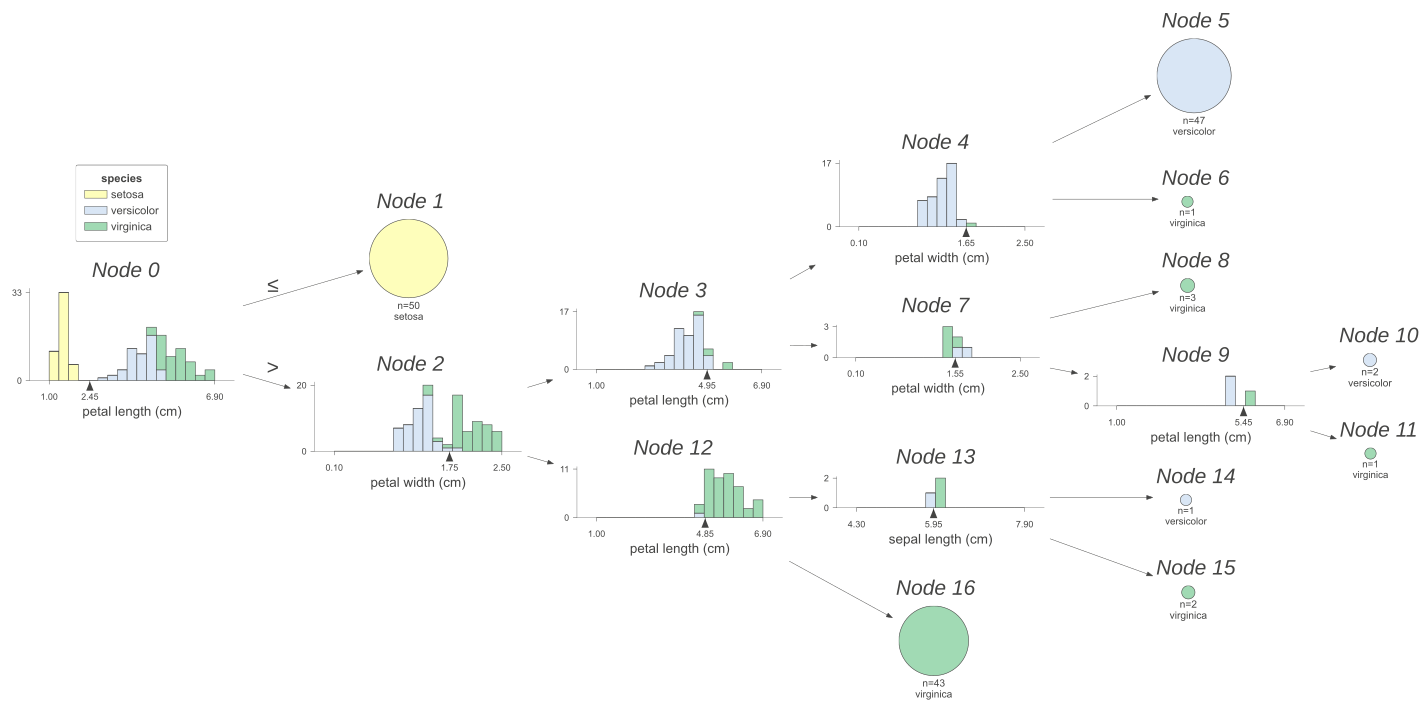

In [8]:
viz.view(
    histtype="barstacked",
    scale=1.5,
    orientation="LR",
    show_node_labels=True
)

## 6. Without any graphs:

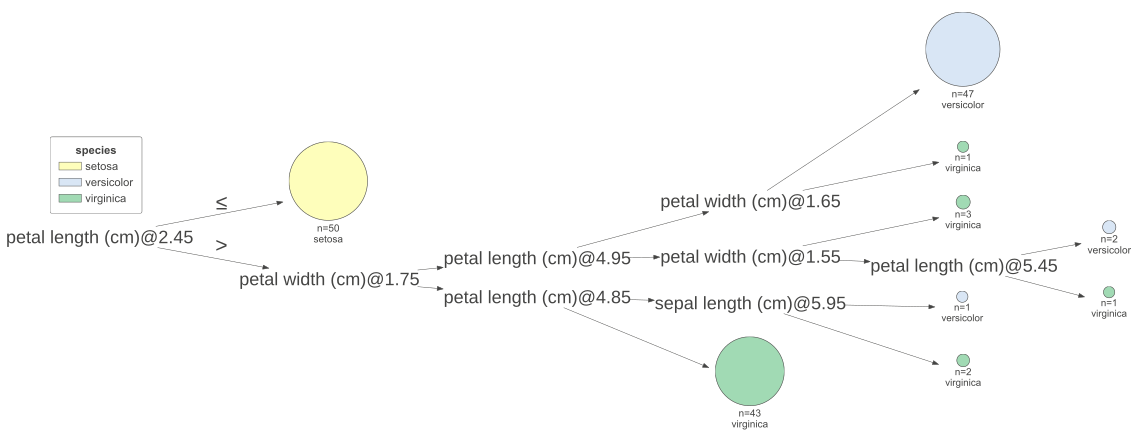

In [9]:
viz.view(
    histtype="barstacked",
    scale=1.5,
    orientation="LR",
    fancy=False
)

## 7. Show just the prediction path, nothing else:

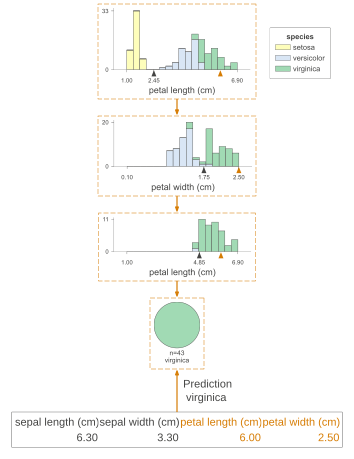

In [10]:
viz.view(x=x_sample, show_just_path=True)

## 8. Prediction path in plain English:

In [11]:
print(viz.explain_prediction_path(x_sample))

4.85 <= petal length (cm) 
1.75 <= petal width (cm) 



## 9. Feature importance:

petal length (cm)    0.5641
petal width (cm)     0.4226
sepal length (cm)    0.0133
sepal width (cm)     0.0000


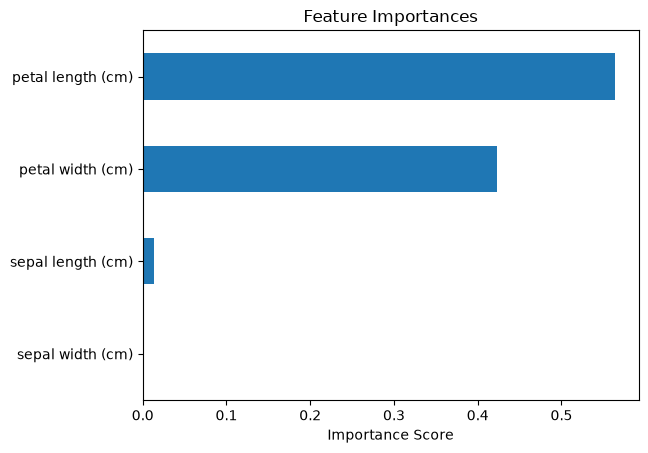

In [12]:
importances = pd.Series(clf.feature_importances_, index=iris.feature_names).sort_values()
print(importances.sort_values(ascending=False).round(4).to_string())

importances.plot(kind="barh")
plt.xlabel("Importance Score")
plt.title("Feature Importances")
plt.show()

## 10. Univariate regression:

In [13]:
df_cars = pd.read_csv('D:/Important Files/Machine Learning/Datasets/cars.csv')
df_cars.head()

,MPG,CYL,ENG,WGT
0,18.0,8,307.0,3504
1,15.0,8,350.0,3693
2,18.0,8,318.0,3436
3,16.0,8,304.0,3433
4,17.0,8,302.0,3449


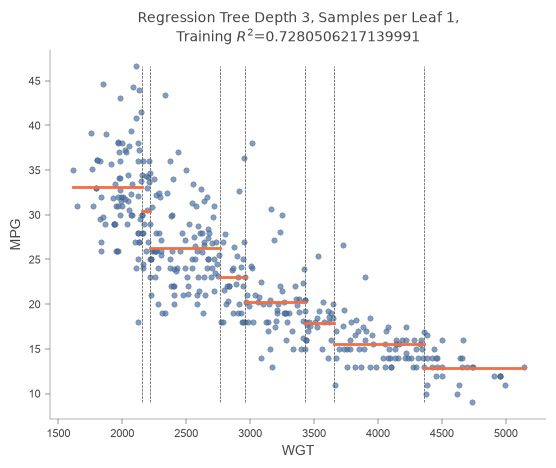

In [14]:
X_cars, y_cars = df_cars[["WGT"]].to_numpy(), df_cars["MPG"].to_numpy()

dt_uni = DecisionTreeRegressor(max_depth=3, criterion="absolute_error", random_state=42)
dt_uni.fit(X_cars, y_cars)

viz_uni = dtreeviz.model(
    dt_uni,
    X_train=X_cars,
    y_train=y_cars,
    feature_names=["WGT"],
    target_name="MPG"
)

fig = plt.figure()
ax = fig.add_subplot(111)
viz_uni.rtree_feature_space(features=["WGT"], ax=ax)
plt.show()

## 11. 3-D regression:

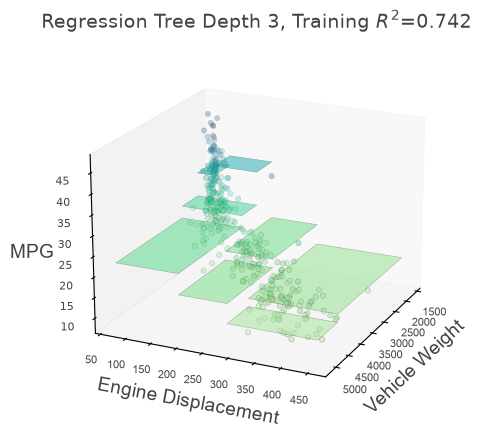

In [15]:
X_cars2 = df_cars[["WGT", "ENG"]].to_numpy()
y_cars2 = df_cars["MPG"].to_numpy()

dt_3d = DecisionTreeRegressor(max_depth=3, criterion="absolute_error", random_state=42)
dt_3d.fit(X_cars2, y_cars)

viz_3d = dtreeviz.model(
    dt_3d,
    X_train=X_cars2,
    y_train=y_cars2,
    feature_names=["Vehicle Weight", "Engine Displacement"],
    target_name="MPG"
)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

viz_3d.rtree_feature_space3D(
    features=["Vehicle Weight", "Engine Displacement"],
    fontsize=14,
    elev=20,
    azim=25,
    dist=8.2,
    show={"splits", "title"},
    ax=ax
)

plt.show()